# Importing the Data


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stat
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
import sklearn.metrics as metrics
from sklearn import feature_selection as fs
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import matplotlib.ticker as ticker

In [2]:
Pima = pd.read_csv('Pima Indians Diabetes\diabetes.csv')

In [3]:
Pima.shape

(768, 9)

In [4]:
Pima.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Preprocessing

## Checking for missing values and zeros

In [5]:
Pima.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

No missing values in this dataset

In [6]:
Pima.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


The minimum is zero for Glucose, Blood Pressure, Skin Thickness, Insulin and BMI. The zeroes in this dataset are almost surely incorrect. We will try ways to deal with the zero data to see how performance is affected. 

In [7]:
Pima.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

All datatypes are numerical, no need for one hot encoding.

In [8]:
names = ['BloodPressure','SkinThickness','Insulin','BMI','Glucose']
obs = Pima.shape[0]
for name in names:
    proportionMissing = Pima[Pima[f'{name}']==0].shape[0]/obs
    print(f'{name} proportion of missing data: {proportionMissing}')

BloodPressure proportion of missing data: 0.045572916666666664
SkinThickness proportion of missing data: 0.2955729166666667
Insulin proportion of missing data: 0.4869791666666667
BMI proportion of missing data: 0.014322916666666666
Glucose proportion of missing data: 0.006510416666666667


Based on this, we will try removing Skin thickness and Insulin variables and impute with mean and median

## Dealing with zeros

In [9]:
PimaMedian = Pima.copy(deep=True)
PimaMean = Pima.copy(deep=True)

### Replace with Median

In [10]:
PimaMedian[PimaMedian['BloodPressure']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
7,10,115,0,0,0,35.3,0.134,29,0
15,7,100,0,0,0,30.0,0.484,32,1
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
78,0,131,0,0,0,43.2,0.270,26,1
81,2,74,0,0,0,0.0,0.102,22,0
172,2,87,0,23,0,28.9,0.773,25,0
193,11,135,0,0,0,52.3,0.578,40,1
222,7,119,0,0,0,25.2,0.209,37,0
261,3,141,0,0,0,30.0,0.761,27,1


The zeroes are going to be replaced with the median of the column

In [11]:
change = ['BloodPressure','SkinThickness','Insulin','BMI','Glucose']
PimaMedian[change] = Pima[change].replace(0,Pima[change].median())
PimaMedian[PimaMedian["BloodPressure"]==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [12]:
PimaMedian.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1
5,5,116,74,23,30.5,25.6,0.201,30,0
6,3,78,50,32,88.0,31.0,0.248,26,1
7,10,115,72,23,30.5,35.3,0.134,29,0
8,2,197,70,45,543.0,30.5,0.158,53,1
9,8,125,96,23,30.5,32.0,0.232,54,1


### Replace with mean

In [13]:
PimaMean[PimaMean['BloodPressure']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
7,10,115,0,0,0,35.3,0.134,29,0
15,7,100,0,0,0,30.0,0.484,32,1
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
78,0,131,0,0,0,43.2,0.270,26,1
81,2,74,0,0,0,0.0,0.102,22,0
172,2,87,0,23,0,28.9,0.773,25,0
193,11,135,0,0,0,52.3,0.578,40,1
222,7,119,0,0,0,25.2,0.209,37,0
261,3,141,0,0,0,30.0,0.761,27,1


In [14]:
PimaMean[change] = PimaMean[change].replace(0,PimaMean[change].mean())
PimaMean[PimaMean["BloodPressure"]==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [15]:
PimaMean.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.000000,35.000000,79.799479,33.600000,0.627,50,1
1,1,85.0,66.000000,29.000000,79.799479,26.600000,0.351,31,0
2,8,183.0,64.000000,20.536458,79.799479,23.300000,0.672,32,1
3,1,89.0,66.000000,23.000000,94.000000,28.100000,0.167,21,0
4,0,137.0,40.000000,35.000000,168.000000,43.100000,2.288,33,1
5,5,116.0,74.000000,20.536458,79.799479,25.600000,0.201,30,0
6,3,78.0,50.000000,32.000000,88.000000,31.000000,0.248,26,1
7,10,115.0,69.105469,20.536458,79.799479,35.300000,0.134,29,0
8,2,197.0,70.000000,45.000000,543.000000,30.500000,0.158,53,1
9,8,125.0,96.000000,20.536458,79.799479,31.992578,0.232,54,1


## Correlation Matrices

### Median Correlation Matrix

Now a correlation matrix is generated for each data set to look for highly correlated variables and variables highly correlated to the target variable.

<Axes: >

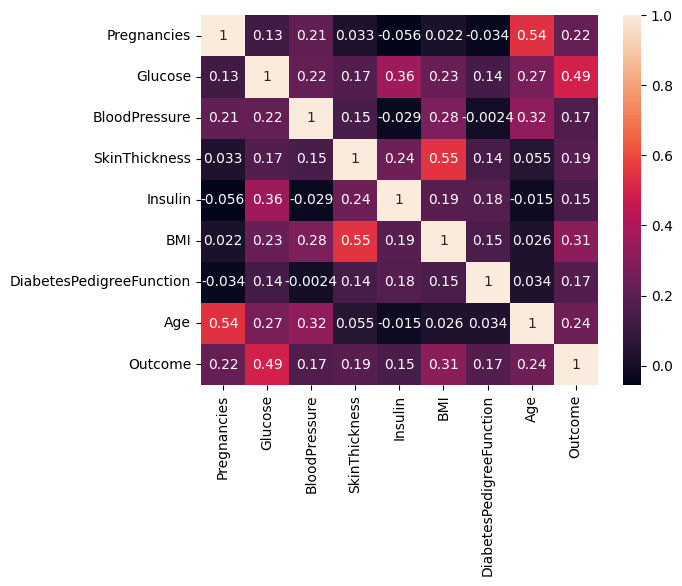

In [16]:
sns.heatmap(PimaMedian.corr(),annot=True)

Age has a correlation of 0.54 to pregnancies, BMI has a correlation of 0.55 to Skin Thickness. 

Glucose has a correlation of 0.49 to the outcome,BMI, Age and Preganancies also have correlation of 0.31,0.24 and 0.22 respectively

### Mean Correlation Matrix

<Axes: >

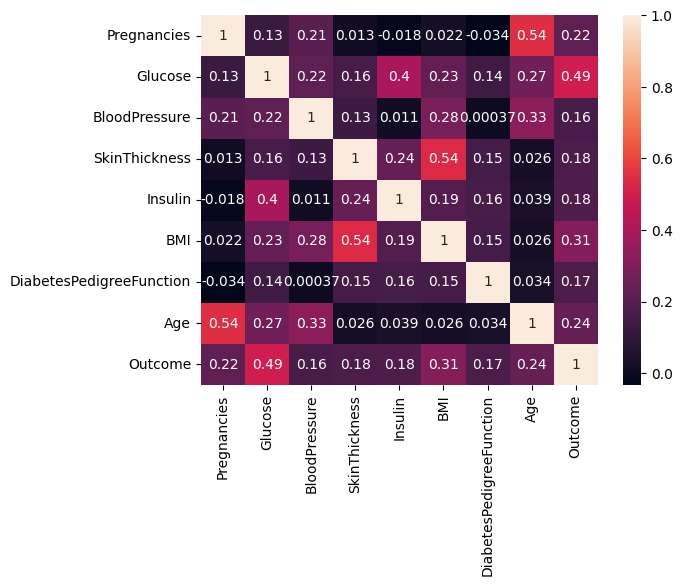

In [17]:
sns.heatmap(PimaMean.corr(),annot=True)

The Age has a correlation of 0.54 with preganacies, Skin thickness ahs a correlation of 0.44 and 0.39 with the insulin and BMI variables.  Glucose has a correlation of 0.47 with the outcome.

## Standardisation

Next each variable is standardised so that all variables are distributed the same way. Some algorithms like the K-Nearest Neighbours perform better with scaled numerical features

### Standardise the Median

In [18]:
names = list(PimaMedian.columns)[:-1]

In [19]:
#standardise the data
for name in names:
    PimaMedian[f'{name}'] = stat.zscore(PimaMedian[f'{name}'])

In [20]:
PimaMedian.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.866045,-0.031990,0.831114,-0.608201,0.167240,0.468492,1.425995,1
1,-0.844885,-1.205066,-0.528319,0.180566,-0.608201,-0.851551,-0.365061,-0.190672,0
2,1.233880,2.016662,-0.693761,-0.469981,-0.608201,-1.331838,0.604397,-0.105584,1
3,-0.844885,-1.073567,-0.528319,-0.469981,-0.006185,-0.633239,-0.920763,-1.041549,0
4,-1.141852,0.504422,-2.679076,0.831114,0.695378,1.549885,5.484909,-0.020496,1


Now all predictor variables are distributed $\mathcal{N}(0,1)$

In [21]:
PimaMedian.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,768.000000
mean,-6.476301e-17,4.625929e-18,5.782412e-18,-1.272131e-16,2.602085e-17,4.672189e-16,2.451743e-16,1.931325e-16,0.348958
std,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,0.476951
min,-1.141852e+00,-2.552931e+00,-4.002619e+00,-2.204774e+00,-7.646304e-01,-2.074100e+00,-1.189553e+00,-1.041549e+00,0.000000
25%,-8.448851e-01,-7.201630e-01,-6.937615e-01,-4.699809e-01,-6.082010e-01,-7.205635e-01,-6.889685e-01,-7.862862e-01,0.000000
50%,-2.509521e-01,-1.530732e-01,-3.198993e-02,-4.699809e-01,-6.010905e-01,-6.562636e-02,-3.001282e-01,-3.608474e-01,0.000000
75%,6.399473e-01,6.112653e-01,6.297816e-01,5.058400e-01,3.090444e-01,6.038649e-01,4.662269e-01,6.602056e-01,1.000000
max,3.906578e+00,2.542658e+00,4.104082e+00,7.770285e+00,7.123206e+00,5.042883e+00,5.883565e+00,4.063716e+00,1.000000


### Standardise the mean

In [22]:
for name in names:
    PimaMean[f'{name}'] = stat.zscore(PimaMean[f'{name}'])

In [23]:
PimaMean.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.865276,-0.021044,0.872057,-0.417768,0.167255,0.468492,1.425995,1
1,-0.844885,-1.205989,-0.516583,0.248678,-0.417768,-0.851535,-0.365061,-0.190672,0
2,1.233880,2.015979,-0.681762,-0.630654,-0.417768,-1.331821,0.604397,-0.105584,1
3,-0.844885,-1.074480,-0.516583,-0.374700,-0.265107,-0.633222,-0.920763,-1.041549,0
4,-1.141852,0.503626,-2.663916,0.872057,0.530423,1.549899,5.484909,-0.020496,1


Now all predictor variables are distributed $\mathcal{N}(0,1)$

In [24]:
PimaMedian.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,768.000000
mean,-6.476301e-17,4.625929e-18,5.782412e-18,-1.272131e-16,2.602085e-17,4.672189e-16,2.451743e-16,1.931325e-16,0.348958
std,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,0.476951
min,-1.141852e+00,-2.552931e+00,-4.002619e+00,-2.204774e+00,-7.646304e-01,-2.074100e+00,-1.189553e+00,-1.041549e+00,0.000000
25%,-8.448851e-01,-7.201630e-01,-6.937615e-01,-4.699809e-01,-6.082010e-01,-7.205635e-01,-6.889685e-01,-7.862862e-01,0.000000
50%,-2.509521e-01,-1.530732e-01,-3.198993e-02,-4.699809e-01,-6.010905e-01,-6.562636e-02,-3.001282e-01,-3.608474e-01,0.000000
75%,6.399473e-01,6.112653e-01,6.297816e-01,5.058400e-01,3.090444e-01,6.038649e-01,4.662269e-01,6.602056e-01,1.000000
max,3.906578e+00,2.542658e+00,4.104082e+00,7.770285e+00,7.123206e+00,5.042883e+00,5.883565e+00,4.063716e+00,1.000000


## Feature Selection

### Median 

The first step is to define the features as target or predictor

In [25]:
Data = PimaMedian.drop(columns='Outcome').values
target = PimaMedian['Outcome']

Next the f-scores for each variable are extracted and displayed as an indexed column array

In [26]:
n=Data.shape[1]

In [27]:
fs_fscore_fit = fs.SelectKBest(fs.f_classif,k=n)
fs_fscore_fit.fit_transform(Data,target)
fs_fscore_indices = np.argsort(np.nan_to_num(fs_fscore_fit.scores_))[::-1][0:n]
fs_fscore_indices

array([1, 5, 7, 0, 3, 6, 2, 4], dtype=int64)

In [28]:
best_features_fscore = PimaMedian.columns[fs_fscore_indices].values
best_features_fscore

array(['Glucose', 'BMI', 'Age', 'Pregnancies', 'SkinThickness',
       'DiabetesPedigreeFunction', 'BloodPressure', 'Insulin'],
      dtype=object)

From F-scores, it can be seen that the most important features are Glucose, BMI, Age and Pregnancies

In [29]:
feature_fscore_importances = fs_fscore_fit.scores_[fs_fscore_indices]
feature_fscore_importances

array([245.66785542,  82.75294974,  46.14061124,  39.67022739,
        28.39627712,  23.8713002 ,  21.63157981,  17.26275997])

In [30]:
%matplotlib inline 
%config InlineBackend.figure_format = 'retina'
plt.style.use("ggplot")

def plot_imp(best_features, scores, method_name):   
    plt.barh(best_features, scores)
    plt.title(method_name + ' Feature Importances')
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.show()

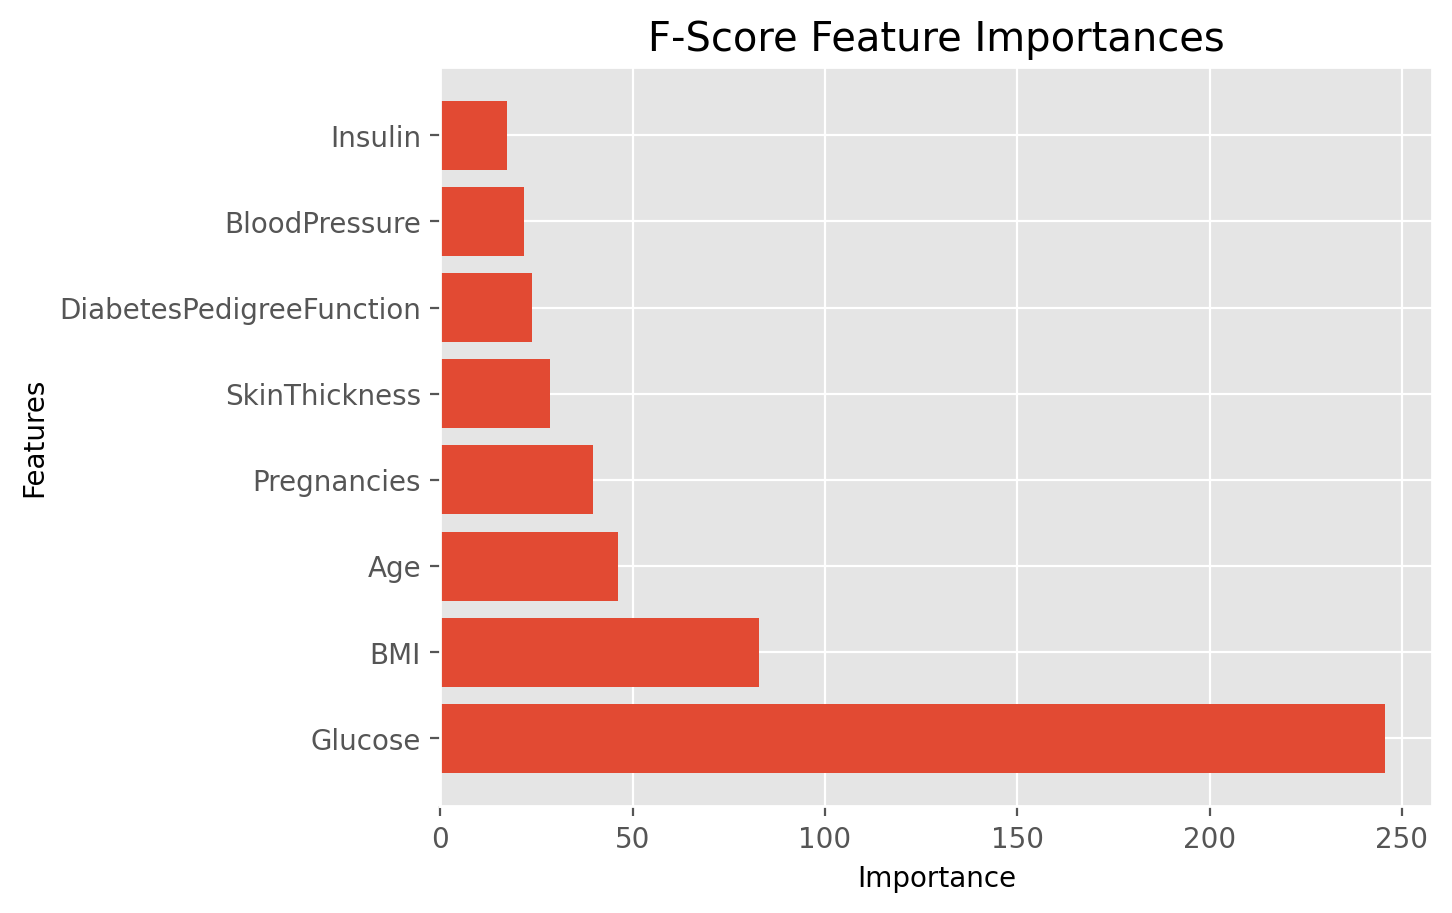

In [31]:
plot_imp(best_features_fscore, feature_fscore_importances, 'F-Score')

### Mean

In [32]:
Data2 = PimaMean.drop(columns='Outcome').values
target2 = PimaMean['Outcome']

In [33]:
fs_fscore_fit2 = fs.SelectKBest(fs.f_classif,k=n)
fs_fscore_fit2.fit_transform(Data2,target2)
fs_fscore_indices2 = np.argsort(np.nan_to_num(fs_fscore_fit2.scores_))[::-1][0:n]
fs_fscore_indices2

array([1, 5, 7, 0, 4, 3, 6, 2], dtype=int64)

In [34]:
best_features_fscore2 = PimaMean.columns[fs_fscore_indices2].values
best_features_fscore2

array(['Glucose', 'BMI', 'Age', 'Pregnancies', 'Insulin', 'SkinThickness',
       'DiabetesPedigreeFunction', 'BloodPressure'], dtype=object)

In [35]:
feature_fscore_importances2 = fs_fscore_fit2.scores_[fs_fscore_indices2]
feature_fscore_importances2

array([245.83385614,  82.75594836,  46.14061124,  39.67022739,
        25.41008862,  24.20727642,  23.8713002 ,  20.9037273 ])

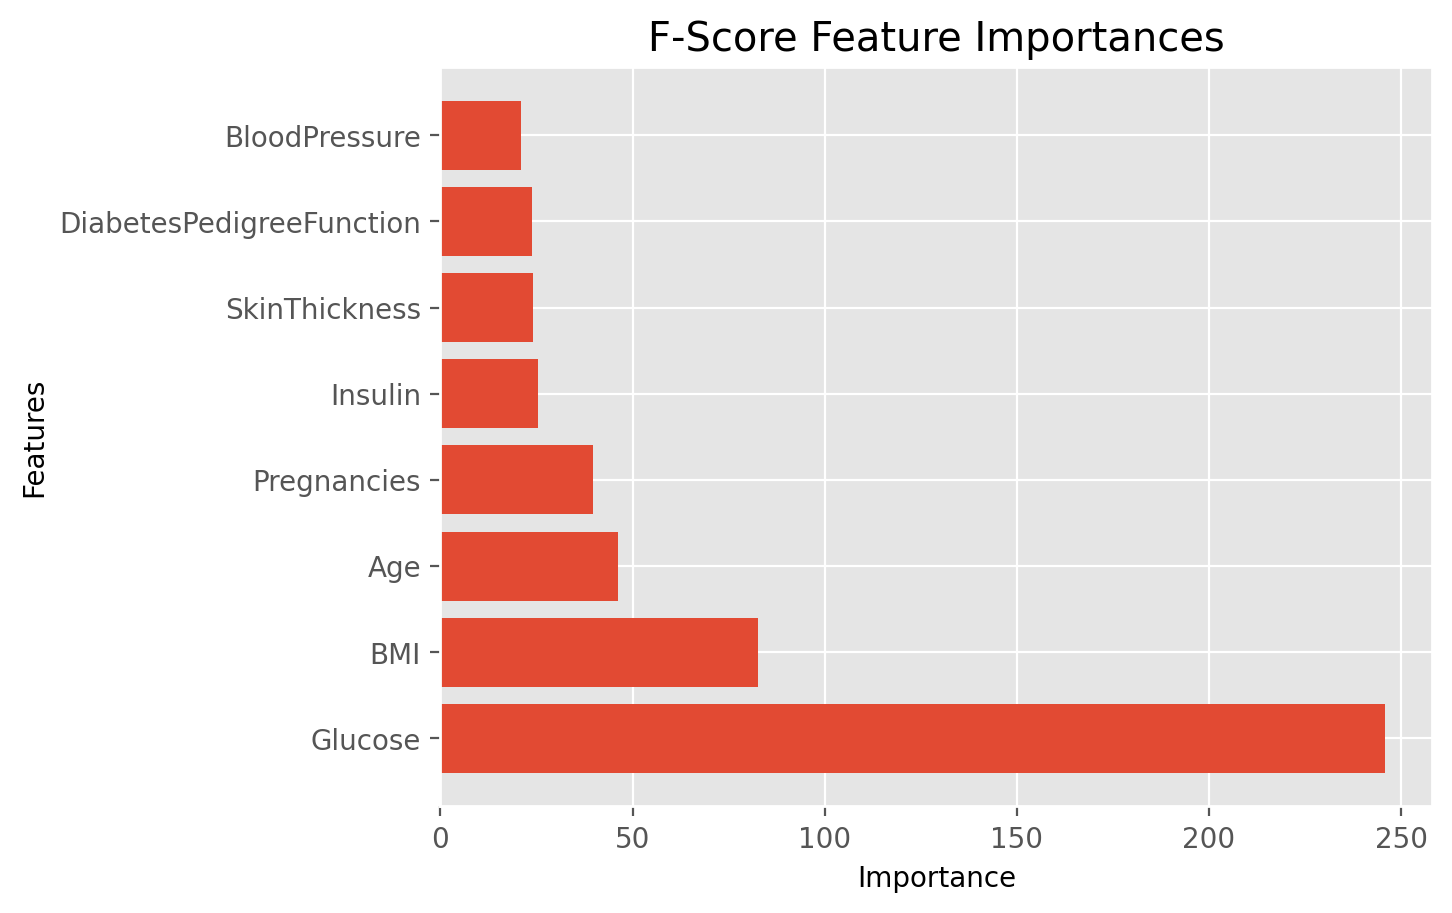

In [36]:
plot_imp(best_features_fscore2, feature_fscore_importances2, 'F-Score')

## Model Fitting and Tuning

Now the data will be split into a train and test dataset.

### Median

In [37]:
median_test,median_train,median_test2,median_train2 = train_test_split(Data,
                                                                      target,
                                                                      test_size=0.2,
                                                                      random_state=999,
                                                                      stratify = target)

### Mean

In [38]:
mean_test,mean_train,mean_test2,mean_train2 = train_test_split(Data2,
                                                              target2,
                                                              test_size=0.2,
                                                              random_state=999,
                                                              stratify = target2)

# Machine Learning Algorithms

## Algorithm 1: K-Nearest Neighbours

The first algorithm to try is the K-NN classifier and compare the results of imputing the mean vs the median

### Median 

In [39]:
knn_classifier = KNeighborsClassifier()

params = {'n_neighbors':[1,2,3,4,5],
         'p':[1,2]}

gs_knn_classifier = GridSearchCV(estimator = knn_classifier,
                                param_grid=params,
                                verbose=1,
                                scoring = ['accuracy','precision','recall','f1'],
                                refit = 'accuracy',
                                cv=10)
gs_knn_classifier.fit(median_train,median_train2)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5], 'p': [1, 2]},
             refit='accuracy',
             scoring=['accuracy', 'precision', 'recall', 'f1'], verbose=1)

In [40]:
print(gs_knn_classifier.best_params_,gs_knn_classifier.best_score_)

{'n_neighbors': 5, 'p': 2} 0.7920833333333335


In [41]:
gs_knn_classifier.cv_results_

{'mean_fit_time': array([0.00139604, 0.00168614, 0.00139098, 0.00139935, 0.00119741,
        0.00099759, 0.00099795, 0.00109921, 0.00080512, 0.00080082]),
 'std_fit_time': array([6.63273778e-04, 7.76507211e-04, 4.92142737e-04, 4.98601509e-04,
        5.94383859e-04, 1.53322982e-05, 4.46865368e-04, 2.85431537e-04,
        4.02788082e-04, 4.00553834e-04]),
 'mean_score_time': array([0.01223025, 0.01212635, 0.01327422, 0.0113328 , 0.00873721,
        0.00794094, 0.0089273 , 0.00743675, 0.00673642, 0.00653768]),
 'std_score_time': array([0.00257302, 0.00362312, 0.00344965, 0.00117971, 0.0012134 ,
        0.00101014, 0.00232346, 0.00066004, 0.0008689 , 0.00064313]),
 'param_n_neighbors': masked_array(data=[1, 1, 2, 2, 3, 3, 4, 4, 5, 5],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value='?',
             dtype=object),
 'param_p': masked_array(data=[1, 2, 1, 2, 1, 2, 1, 2, 1, 2],
              mask=[False, False,

In [42]:
s = {'n_neighbours':[1,1,2,2,3,3,4,4,5,5],
     'p':[1,2,1,2,1,2,1,2,1,2],
    'Accuracy':gs_knn_classifier.cv_results_['mean_test_accuracy'],
    'Recall':gs_knn_classifier.cv_results_['mean_test_recall'],
    'Precision':gs_knn_classifier.cv_results_['mean_test_precision'],
    'F1':gs_knn_classifier.cv_results_['mean_test_f1']}
KNN_data = pd.DataFrame(s)

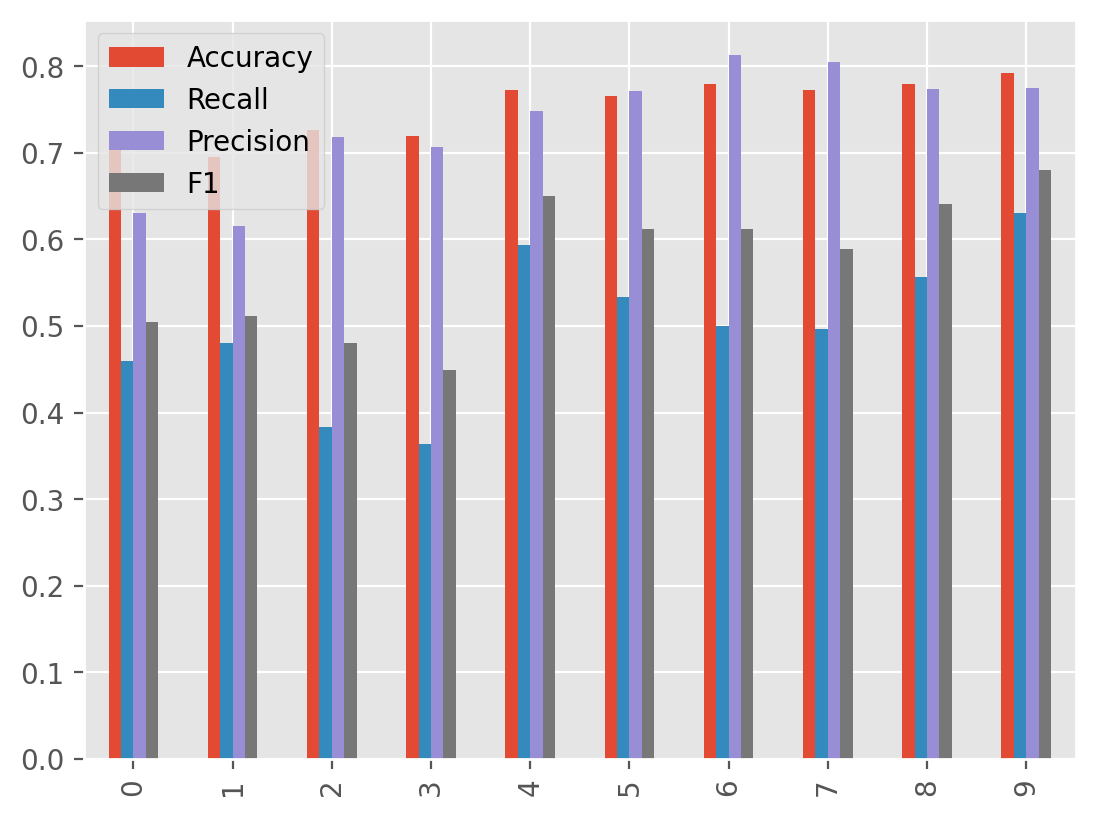

In [43]:
KNN_data.iloc[:,2:].plot.bar();

### Mean

In [44]:
knn_classifier2 = KNeighborsClassifier()

params = {'n_neighbors':[1,2,3,4,5],
         'p':[1,2]}

gs_knn_classifier2 = GridSearchCV(estimator = knn_classifier2,
                                param_grid=params,
                                verbose=1,
                                scoring = ['accuracy','precision','recall','f1'],
                                refit = 'accuracy',
                                cv=10)
gs_knn_classifier2.fit(mean_train,mean_train2)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5], 'p': [1, 2]},
             refit='accuracy',
             scoring=['accuracy', 'precision', 'recall', 'f1'], verbose=1)

In [45]:
print(gs_knn_classifier2.best_params_,gs_knn_classifier2.best_score_)

{'n_neighbors': 3, 'p': 1} 0.7920833333333333


In [46]:
s = {'n_neighbours':[1,1,2,2,3,3,4,4,5,5],
     'p':[1,2,1,2,1,2,1,2,1,2],
    'Accuracy':gs_knn_classifier.cv_results_['mean_test_accuracy'],
    'Recall':gs_knn_classifier.cv_results_['mean_test_recall'],
    'Precision':gs_knn_classifier.cv_results_['mean_test_precision'],
    'F1':gs_knn_classifier.cv_results_['mean_test_f1']}
KNN_data_mean = pd.DataFrame(s)

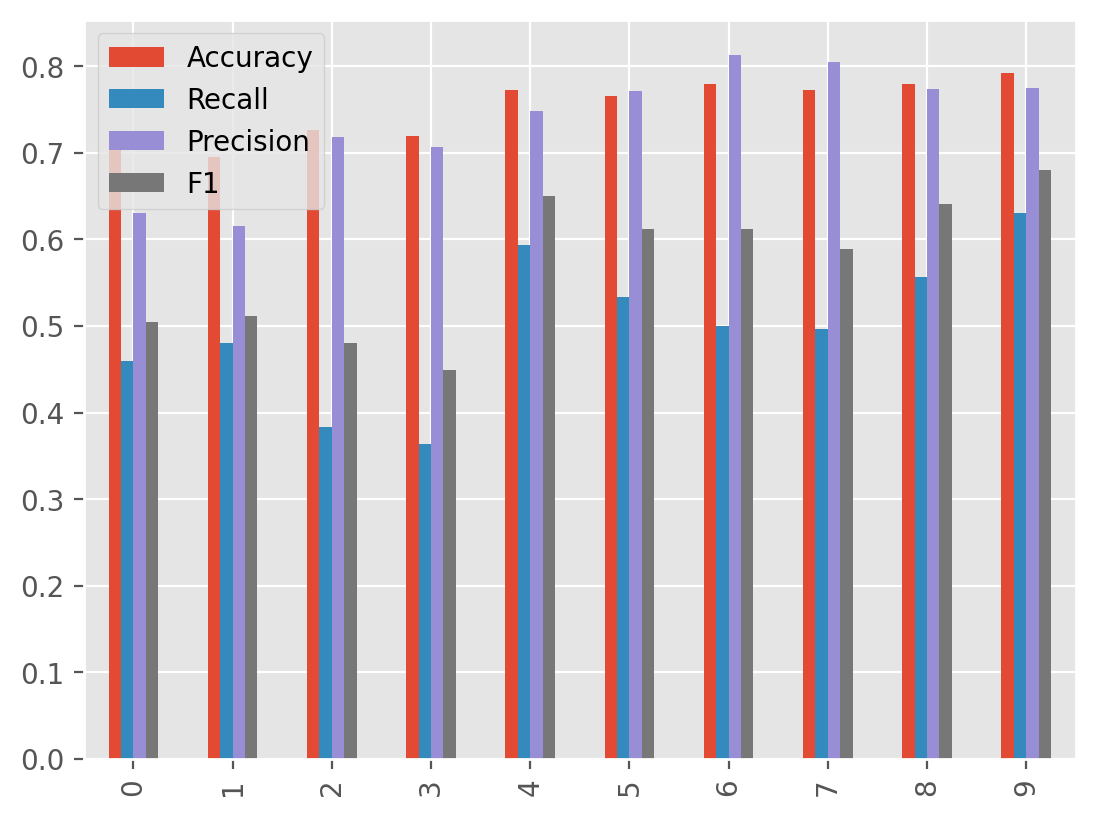

In [47]:
KNN_data_mean.iloc[:,2:].plot.bar();

### Dropping Skin Thickness and Insulin Variables

#### Mean

In [48]:
Pima_drop_var_mean = pd.DataFrame(Data2,columns = names)
Pima_drop_var_mean = Pima_drop_var_mean.drop(columns = ['SkinThickness','Insulin'],axis=1).values

In [49]:
mean_drop_test,mean_drop_train,mean_drop_test2,mean_drop_train2 = train_test_split(Pima_drop_var_mean,
                                                                      target,
                                                                      test_size=0.2,
                                                                      random_state=999)

In [50]:
knn_classifier3 = KNeighborsClassifier()

params = {'n_neighbors':[1,2,3,4,5],
         'p':[1,2]}

gs_knn_classifier3 = GridSearchCV(estimator = knn_classifier3,
                                param_grid=params,
                                verbose=1,
                                scoring = ['accuracy','precision','recall','f1'],
                                refit = 'accuracy',
                                cv=5)
gs_knn_classifier3.fit(mean_drop_train,mean_drop_train2)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5], 'p': [1, 2]},
             refit='accuracy',
             scoring=['accuracy', 'precision', 'recall', 'f1'], verbose=1)

In [51]:
print(gs_knn_classifier3.best_params_,gs_knn_classifier3.best_score_)

{'n_neighbors': 4, 'p': 2} 0.766236559139785


In [52]:
gs_knn_classifier3.cv_results_

{'mean_fit_time': array([0.00119748, 0.00039935, 0.00099783, 0.00059276, 0.00039921,
        0.00079823, 0.00079803, 0.00099721, 0.00059838, 0.0009975 ]),
 'std_fit_time': array([9.76914065e-04, 4.89103707e-04, 1.12234137e-06, 4.84138297e-04,
        4.88928058e-04, 3.99113414e-04, 3.99017391e-04, 1.90734863e-07,
        4.88577633e-04, 1.78416128e-07]),
 'mean_score_time': array([0.00907702, 0.00718036, 0.00719476, 0.00689502, 0.00717311,
        0.00718126, 0.00678167, 0.00678225, 0.00668316, 0.00678167]),
 'std_score_time': array([0.00264486, 0.00039809, 0.00039287, 0.00016985, 0.00073924,
        0.00039871, 0.0003988 , 0.00039897, 0.00039826, 0.00039892]),
 'param_n_neighbors': masked_array(data=[1, 1, 2, 2, 3, 3, 4, 4, 5, 5],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value='?',
             dtype=object),
 'param_p': masked_array(data=[1, 2, 1, 2, 1, 2, 1, 2, 1, 2],
              mask=[False, False,

In [53]:
s = {'n_neighbours':[1,1,2,2,3,3,4,4,5,5],
     'p':[1,2,1,2,1,2,1,2,1,2],
    'Accuracy':gs_knn_classifier.cv_results_['mean_test_accuracy'],
    'Recall':gs_knn_classifier.cv_results_['mean_test_recall'],
    'Precision':gs_knn_classifier.cv_results_['mean_test_precision'],
    'F1':gs_knn_classifier.cv_results_['mean_test_f1']}
KNN_data = pd.DataFrame(s)

<Axes: >

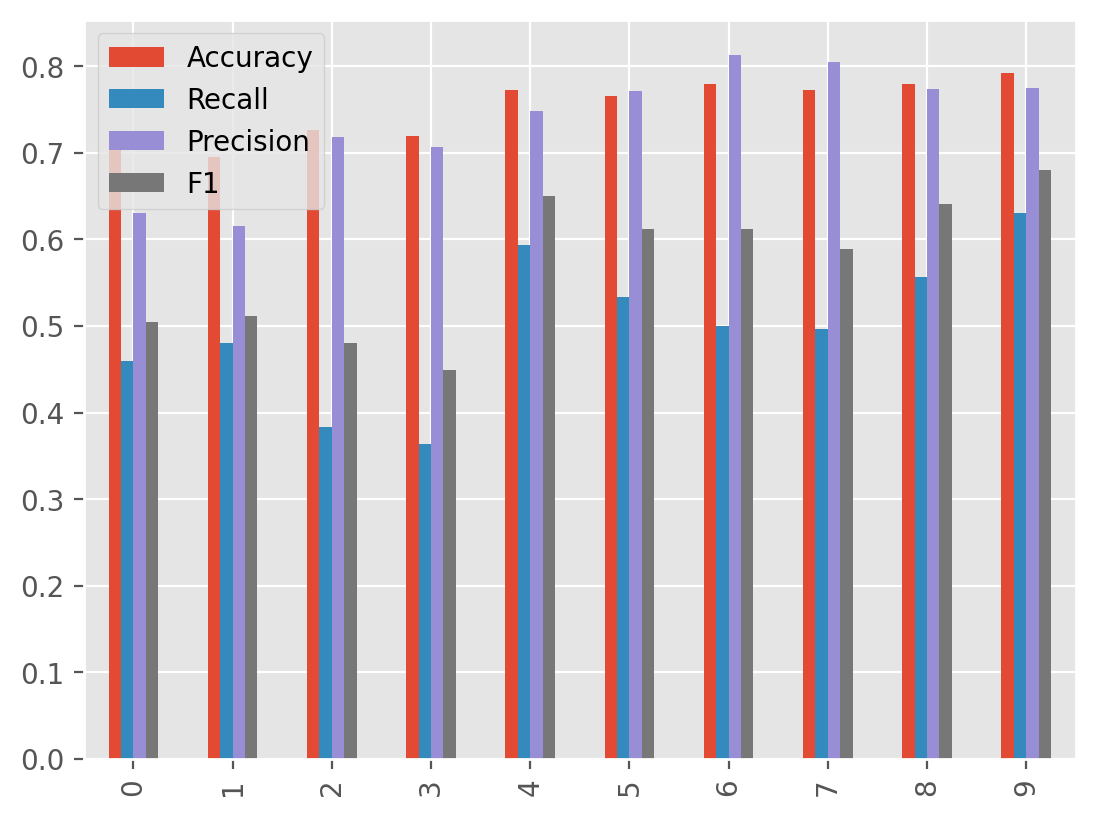

In [54]:
KNN_data.iloc[:,2:].plot(kind='bar')

#### Median

In [55]:
Pima_drop_var_median = pd.DataFrame(Data,columns = names)
Pima_drop_var_median = Pima_drop_var_median.drop(columns = ['SkinThickness','Insulin'],axis=1).values

In [56]:
median_drop_test1,median_drop_train1,median_drop_test2,median_drop_train2 = train_test_split(Pima_drop_var_median,
                                                                      target,
                                                                      test_size=0.2,
                                                                      random_state=999)

In [57]:
knn_classifier4 = KNeighborsClassifier()

params = {'n_neighbors':[1,2,3,4,5],
         'p':[1,2]}

gs_knn_classifier4 = GridSearchCV(estimator = knn_classifier4,
                                param_grid=params,
                                verbose=1,
                                scoring = ['accuracy','precision','recall','f1'],
                                refit = 'accuracy',
                                cv=5)
gs_knn_classifier4.fit(median_drop_train1,median_drop_train2)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5], 'p': [1, 2]},
             refit='accuracy',
             scoring=['accuracy', 'precision', 'recall', 'f1'], verbose=1)

In [58]:
print(gs_knn_classifier4.best_params_,gs_knn_classifier4.best_score_)

{'n_neighbors': 4, 'p': 2} 0.7595698924731182


In [59]:
knn4 = {'n_neighbours':[1,1,2,2,3,3,4,4,5,5],
     'p':[1,2,1,2,1,2,1,2,1,2],
    'Accuracy':gs_knn_classifier4.cv_results_['mean_test_accuracy'],
    'Recall':gs_knn_classifier4.cv_results_['mean_test_recall'],
    'Precision':gs_knn_classifier4.cv_results_['mean_test_precision'],
    'F1':gs_knn_classifier4.cv_results_['mean_test_f1']}
KNN_data4 = pd.DataFrame(knn4)

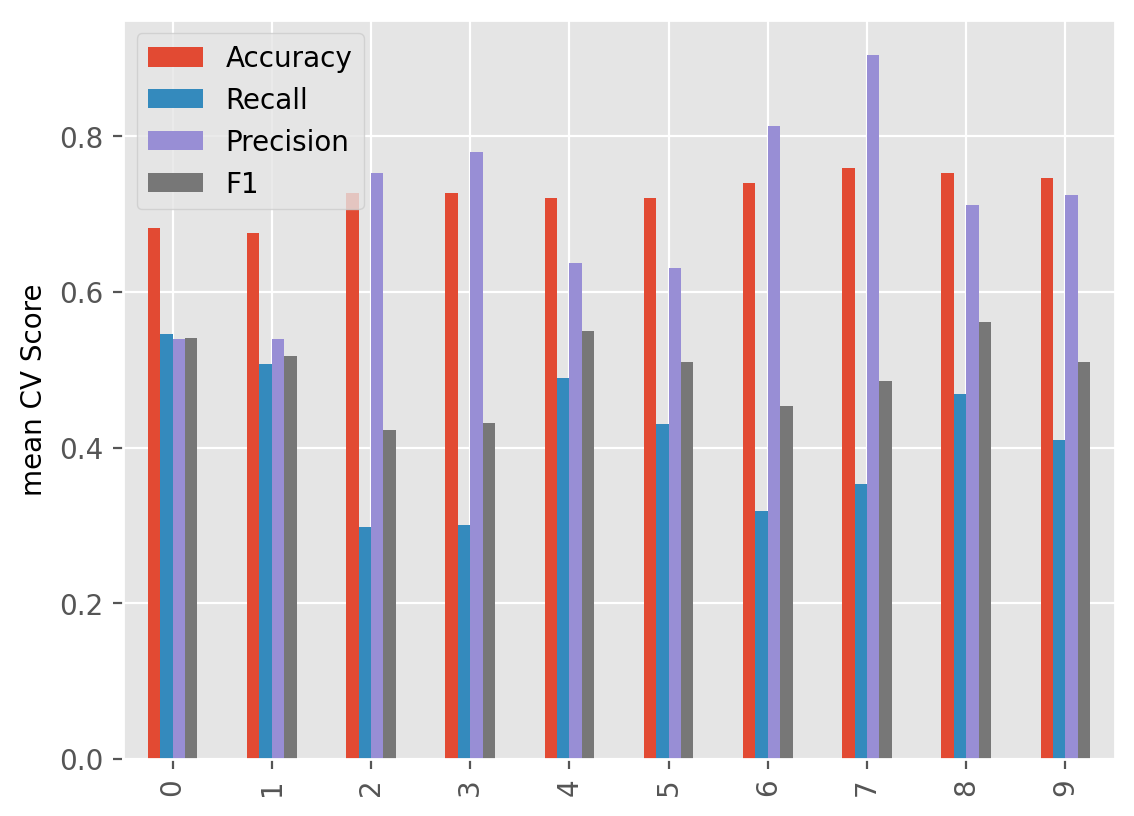

In [60]:
ax = KNN_data4.iloc[:,2:].plot(kind='bar')
ax.set_ylabel('mean CV Score');

It seems that dropping columns of data with a high proportion of imputed data increases the accuracy of the K-NN algorithm. Across 3 of the tests the best parameters were using $K=4$ and using euclidean distance as the metric. The best accuracy was obtained using the mean imputation and dropping the Insulin and SkinThickness variables.

### Results of the K-NN algorithm

Now the results of each dataset are evaluated and looked at more in depth. This is done by comparing the accuracies of each combination of distance type and number of neighbours.

#### Median

In [61]:
KNN_results_median = pd.DataFrame(gs_knn_classifier4.cv_results_['params'])
KNN_results_median['test_score'] = gs_knn_classifier4.cv_results_['mean_test_score']
KNN_results_median['metric']=KNN_results_median['p'].replace([1,2],['Manhattan','Euclidean'])
KNN_results_median

KeyError: 'mean_test_score'

In [ ]:
%matplotlib inline 
%config InlineBackend.figure_format = 'retina'
plt.style.use("ggplot")

for i in ["Manhattan", "Euclidean", "Minkowski"]:
    temp = KNN_results_median[KNN_results_median['metric'] == i]
    plt.plot(temp['n_neighbors'], temp['test_score'], marker = '.', label = i)
    
plt.legend()
plt.xlabel('Number of Neighbors')
plt.ylabel("Mean CV Score")
plt.title("KNN Performance Comparison Median Imputation")
plt.show()

#### Mean

In [ ]:
KNN_results_mean = pd.DataFrame(gs_knn_classifier2.cv_results_['params'])
KNN_results_mean['test_score'] = gs_knn_classifier2.cv_results_['mean_test_score']
KNN_results_mean['metric']=KNN_results_mean['p'].replace([1,2,5],['Manhattan','Euclidean','Minkowski'])
KNN_results_mean

In [ ]:
for i in ["Manhattan", "Euclidean", "Minkowski"]:
    temp = KNN_results_mean[KNN_results_mean['metric'] == i]
    plt.plot(temp['n_neighbors'], temp['test_score'], marker = '.', label = i)
    
plt.legend()
plt.xlabel('Number of Neighbors')
plt.ylabel("Mean CV Score")
plt.title("KNN Performance Comparison Mean Imputation")
plt.show()

#### Mean dropped variables

In [ ]:
KNN_results_dropped_mean = pd.DataFrame(gs_knn_classifier3.cv_results_['params'])
KNN_results_dropped_mean['test_score'] = gs_knn_classifier3.cv_results_['mean_test_score']
KNN_results_dropped_mean['metric']=KNN_results_mean['p'].replace([1,2,5],['Manhattan','Euclidean','Minkowski'])
KNN_results_dropped_mean

In [ ]:
for i in ["Manhattan", "Euclidean", "Minkowski"]:
    temp = KNN_results_mean[KNN_results_mean['metric'] == i]
    plt.plot(temp['n_neighbors'], temp['test_score'], marker = '.', label = i)
    
plt.legend()
plt.xlabel('Number of Neighbors')
plt.ylabel("Mean CV Score")
plt.title("KNN Performance Comparison mean imputation \n SkinThickness and Insulin Dropped")
plt.show()

#### Median dropped variables

In [ ]:
KNN_results_dropped_median = pd.DataFrame(gs_knn_classifier4.cv_results_['params'])
KNN_results_dropped_median['test_score'] = gs_knn_classifier4.cv_results_['mean_test_score']
KNN_results_dropped_median['metric']=KNN_results_mean['p'].replace([1,2,5],['Manhattan','Euclidean','Minkowski'])
KNN_results_dropped_median

In [ ]:
for i in ["Manhattan", "Euclidean", "Minkowski"]:
    temp = KNN_results_mean[KNN_results_mean['metric'] == i]
    plt.plot(temp['n_neighbors'], temp['test_score'], marker = '.', label = i)
    
plt.legend()
plt.xlabel('Number of Neighbors')
plt.ylabel("Mean CV Score")
plt.title("KNN Performance Comparison median imputation \n SkinThickness and Insulin Dropped")
plt.show()

## Algorithm 2: Decision Tree Classifier

The next algorithm that we are going to use is the Decision Tree Classifier. Once again all for variations of the preprocessed data will be tried

In [ ]:
dt_classifier1 = DecisionTreeClassifier(random_state=999)

params_DT = {'criterion':['gini','entropy'],
            'max_depth':[x for x in range(1,9)],
            'min_samples_split':[2,3]}

gs_DT1 = GridSearchCV(estimator = dt_classifier1,
                    param_grid = params_DT,
                    cv=5,
                    verbose=1,
                    scoring='accuracy')
gs_DT1.fit(median_train,median_train2)

In [ ]:
print(gs_DT1.best_params_,gs_DT1.best_score_)

In [ ]:
DT_results1 = pd.DataFrame(gs_DT1.cv_results_['params'])
DT_results1['test_score']=gs_DT1.cv_results_['mean_test_score']

In [ ]:
for i in DT_results1['min_samples_split'].unique():
    temp1 = DT_results1[(DT_results1['min_samples_split'] == i) & (DT_results1['criterion']=='entropy')]
    temp2 = DT_results1[(DT_results1['min_samples_split'] == i) & (DT_results1['criterion']=='gini')]
    plt.tight_layout()
    plt.subplot(2,1,1)
    plt.plot(temp1['max_depth'], temp1['test_score'], marker = '.', label = 'min_samples_split: ' + str(i))
    plt.title("Decision Tree Performance Comparison Entropy")
    plt.legend()
    plt.xlabel('Max Depth')
    plt.ylabel("Mean CV Score") 
    plt.subplot(2,1,2)
    plt.plot(temp2['max_depth'], temp2['test_score'], marker = '.', label = 'min_samples_split: ' + str(i))
    plt.title("Decision Tree Performance Comparison gini index")
    plt.legend()
    plt.xlabel('Max Depth')
    plt.ylabel("Mean CV Score") 


plt.show()

## Algorithm 3: Logistic Regression

### Median

In [ ]:
lr_classifier1 = LogisticRegression()

params_LR = {'penalty':['l2'],
            'C':[1/c for c in [1,3,5,7,9]]} 
gs_lr = GridSearchCV(estimator = lr_classifier1,
                    cv=10,
                    verbose=1,
                    param_grid=params_LR,
                    scoring = ['accuracy','precision','recall','f1'],
                     refit = 'accuracy')
gs_lr.fit(median_train,median_train2)

In [ ]:
lr_classifier_nopen1 = LogisticRegression()
param_grid_nopen = {'penalty':[None]}
gs_lr_nopen1 = GridSearchCV(estimator = lr_classifier1,
                    cv=10,
                    verbose=1,
                    param_grid = param_grid_nopen,
                    scoring = ['accuracy','precision','recall','f1'],
                     refit = 'accuracy')
gs_lr_nopen1.fit(median_train,median_train2)

In [ ]:
gs_lr_nopen1.cv_results_

In [ ]:
s = {'C':[1,1/3,1/5,1/7,1/9,0],
    'Accuracy':np.concatenate((gs_lr.cv_results_['mean_test_accuracy'],gs_lr_nopen1.cv_results_['mean_test_accuracy'])),
    'Recall':np.concatenate((gs_lr.cv_results_['mean_test_recall'],gs_lr_nopen1.cv_results_['mean_test_recall'])),
    'Precision':np.concatenate((gs_lr.cv_results_['mean_test_precision'],gs_lr_nopen1.cv_results_['mean_test_precision'])),
    'F1':np.concatenate((gs_lr.cv_results_['mean_test_precision'],gs_lr_nopen1.cv_results_['mean_test_precision']))}
pd.DataFrame(s)

### Mean

In [ ]:
lr_classifier2 = LogisticRegression()


gs_lr2 = GridSearchCV(estimator = lr_classifier2,
                    cv=10,
                    verbose=1,
                    param_grid=params_LR,
                    scoring = ['accuracy','precision','recall','f1'],
                     refit = 'accuracy')
gs_lr2.fit(mean_train,mean_train2)

In [ ]:
print(gs_lr2.best_params_,gs_lr2.best_score_)

In [ ]:
gs_lr2.cv_results_

In [ ]:
s = {'C':[1,1/3,1/5,1/7,1/9,0],
    'Accuracy':gs_lr2.cv_results_['mean_test_accuracy'],
    'Recall':gs_lr2.cv_results_['mean_test_recall'],
    'Precision':gs_lr2.cv_results_['mean_test_precision'],
    'F1':gs_lr2.cv_results_['mean_test_f1']}
pd.DataFrame(s)

## Algorithm 4: Random Forest Classifier 

### Median 

In [ ]:
rf_classifier = RandomForestClassifier()

params_RF = params_DT = {'criterion':['gini','entropy'],
            'max_depth':[x for x in range(1,9)],
            'min_samples_split':[2,3]}

rf_gs1 = GridSearchCV(estimator = rf_classifier,
                    cv=10,
                    verbose=1,
                    param_grid=params_RF,
                    scoring = ['accuracy','precision','recall','f1'],
                     refit = 'accuracy') 
rf_gs1.fit(median_train,median_train2)

## Algorithm 5: Support Vector Machine

In [ ]:
SVM_classifier = SVC(kernel = 'linear')
params_SVC = {'C':[1/c for c in [1,3,5,7]]}

gs_SVR = GridSearchCV(estimator = SVM_classifier, param_grid = params_SVC, 
                          cv = 10, n_jobs = -1, verbose = 2,
                    scoring = ['accuracy','precision','recall','f1'],
                     refit = 'accuracy')
gs_SVR.fit(mean_train,mean_train2)

In [ ]:
print(gs_SVR.best_params_,gs_SVR.best_score_)